# Etap 2 – Predykcja sukcesu kampanii Kickstarter

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, roc_curve, ConfusionMatrixDisplay
)
import lightgbm as lgb

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

In [14]:
import os
os.makedirs('phase2', exist_ok=True)

Folder phase2/ gotowy.


## 1. Wczytanie i czyszczenie danych

In [16]:
df = pd.read_csv('data/ks-projects-201801.csv', encoding='latin1')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df = df.drop(columns=['usd_pledged'], errors='ignore')
df = df.dropna(subset=['name'])

df['deadline'] = pd.to_datetime(df['deadline'])
df['launched'] = pd.to_datetime(df['launched'])
df = df[df['launched'] > '2009-01-01']

for col in ['goal', 'usd_goal_real']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_model = df[df['state'].isin(['successful', 'failed'])].copy()
df_model['success'] = (df_model['state'] == 'successful').astype(int)
df_model = df_model[df_model['usd_goal_real'] >= 1].copy()

print(f'Rozmiar zbioru: {df_model.shape[0]:,}')
print(f'Sukces: {df_model["success"].mean():.1%}')

Rozmiar zbioru: 331,644
Sukces: 40.4%


## 2. Inżynieria cech

In [17]:
df_model['campaign_days']   = (df_model['deadline'] - df_model['launched'].dt.normalize()).dt.days
df_model['launch_year']     = df_model['launched'].dt.year
df_model['launch_month']    = df_model['launched'].dt.month
df_model['launch_dayofweek']= df_model['launched'].dt.dayofweek
df_model['launch_quarter']  = df_model['launched'].dt.quarter

df_model['log_goal']        = np.log1p(df_model['usd_goal_real'])
df_model['goal_per_day']    = df_model['usd_goal_real'] / df_model['campaign_days'].replace(0, np.nan)
df_model['log_goal_per_day']= np.log1p(df_model['goal_per_day'])

df_model['name_length']     = df_model['name'].str.split().str.len()
df_model['is_usa']          = (df_model['country'] == 'US').astype(int)

top_countries = df_model['country'].value_counts().head(10).index
df_model['country_grouped'] = df_model['country'].where(
    df_model['country'].isin(top_countries), 'Other'
)

NUM_FEATURES = [
    'log_goal', 'log_goal_per_day', 'campaign_days',
    'name_length', 'launch_month', 'launch_dayofweek',
    'launch_year', 'launch_quarter', 'is_usa'
]
CAT_FEATURES = ['main_category', 'category', 'country_grouped']
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET = 'success'

print('Cechy numeryczne:', NUM_FEATURES)
print('Cechy kategoryczne:', CAT_FEATURES)

Cechy numeryczne: ['log_goal', 'log_goal_per_day', 'campaign_days', 'name_length', 'launch_month', 'launch_dayofweek', 'launch_year', 'launch_quarter', 'is_usa']
Cechy kategoryczne: ['main_category', 'category', 'country_grouped']


## 3. Podział danych i pipeline

In [18]:
X = df_model[ALL_FEATURES]
y = df_model[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler())
    ]), NUM_FEATURES),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), CAT_FEATURES)
])

Train: 232,150  Val: 49,747  Test: 49,747


## 4. Modele bazowe

In [19]:
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                               random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                   n_jobs=-1, random_state=RANDOM_STATE),
    'LightGBM':            lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                               class_weight='balanced',
                                               random_state=RANDOM_STATE, verbose=-1),
}

results = []
trained_pipes = {}

for name, clf in base_models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    trained_pipes[name] = pipe

    y_pred  = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]
    results.append({
        'Model':    name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'F1':       f1_score(y_val, y_pred),
        'AUC-ROC':  roc_auc_score(y_val, y_proba),
    })
    print(f'{name:25s}  Acc={results[-1]["Accuracy"]:.4f}  F1={results[-1]["F1"]:.4f}  AUC={results[-1]["AUC-ROC"]:.4f}')

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)
results_df

Logistic Regression        Acc=0.6631  F1=0.6173  AUC=0.7254
Random Forest              Acc=0.6833  F1=0.5695  AUC=0.7359
LightGBM                   Acc=0.6816  F1=0.6432  AUC=0.7550


,Model,Accuracy,F1,AUC-ROC
2,LightGBM,0.681569,0.643181,0.754957
1,Random Forest,0.683297,0.569524,0.735889
0,Logistic Regression,0.663075,0.617268,0.725359


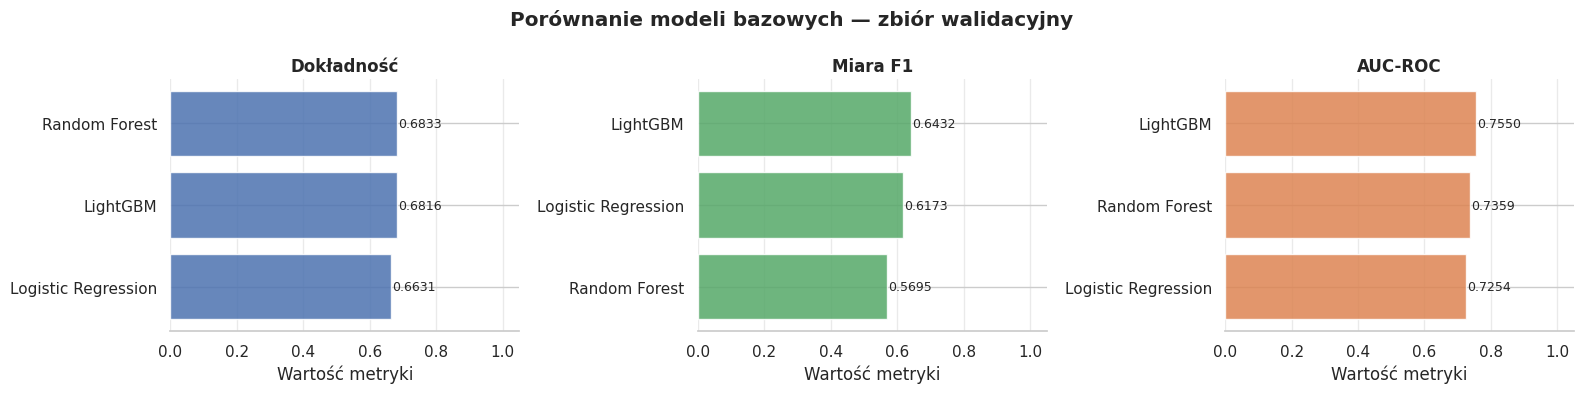

In [20]:
metric_labels = {'Accuracy': 'Dokładność', 'F1': 'Miara F1', 'AUC-ROC': 'AUC-ROC'}
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics = ['Accuracy', 'F1', 'AUC-ROC']
colors  = ['#4C72B0', '#55A868', '#DD8452']

for ax, metric, color in zip(axes, metrics, colors):
    df_plot = results_df.sort_values(metric)
    bars = ax.barh(df_plot['Model'], df_plot[metric], color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, df_plot[metric]):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_title(metric_labels[metric], fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Wartość metryki')
    sns.despine(ax=ax, left=True)
    ax.grid(axis='x', alpha=0.4)

plt.suptitle('Porównanie modeli bazowych — zbiór walidacyjny', fontweight='bold')
plt.tight_layout()
plt.savefig('phase2/fig1_modele_bazowe.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Strojenie hiperparametrów LightGBM

In [21]:
param_dist = {
    'clf__n_estimators':      [200, 400, 600],
    'clf__learning_rate':     [0.03, 0.05, 0.1],
    'clf__num_leaves':        [31, 63, 127],
    'clf__max_depth':         [-1, 8, 12],
    'clf__min_child_samples': [20, 50, 100],
    'clf__subsample':         [0.7, 0.85, 1.0],
    'clf__colsample_bytree':  [0.7, 0.85, 1.0],
    'clf__reg_alpha':         [0.0, 0.1, 0.5],
    'clf__reg_lambda':        [0.0, 0.5, 1.0],
}

lgbm_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  lgb.LGBMClassifier(class_weight='balanced',
                                 random_state=RANDOM_STATE, verbose=-1))
])

search = RandomizedSearchCV(
    lgbm_pipe, param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=3
)
search.fit(X_train, y_train)

print(f'Najlepszy AUC-ROC (CV): {search.best_score_:.4f}')
for k, v in sorted(search.best_params_.items()):
    print(f'  {k}: {v}')

best_model = search.best_estimator_
y_val_pred  = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]
print(f'\nLightGBM (strojony) – val:  Acc={accuracy_score(y_val, y_val_pred):.4f}  '
      f'F1={f1_score(y_val, y_val_pred):.4f}  AUC={roc_auc_score(y_val, y_val_proba):.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END clf__colsample_bytree=1.0, clf__learning_rate=0.05, clf__max_depth=-1, clf__min_child_samples=100, clf__n_estimators=200, clf__num_leaves=31, clf__reg_alpha=0.0, clf__reg_lambda=0.0, clf__subsample=0.7;, score=0.760 total time=   2.0s
[CV 2/5] END clf__colsample_bytree=1.0, clf__learning_rate=0.05, clf__max_depth=-1, clf__min_child_samples=100, clf__n_estimators=200, clf__num_leaves=31, clf__reg_alpha=0.0, clf__reg_lambda=0.0, clf__subsample=0.7;, score=0.757 total time=   3.4s
[CV 3/5] END clf__colsample_bytree=1.0, clf__learning_rate=0.05, clf__max_depth=-1, clf__min_child_samples=100, clf__n_estimators=200, clf__num_leaves=31, clf__reg_alpha=0.0, clf__reg_lambda=0.0, clf__subsample=0.7;, score=0.757 total time=   2.1s
[CV 4/5] END clf__colsample_bytree=1.0, clf__learning_rate=0.05, clf__max_depth=-1, clf__min_child_samples=100, clf__n_estimators=200, clf__num_leaves=31, clf__reg_alpha=0.0, clf__reg_lambda=0.0

## 6. Ważność cech

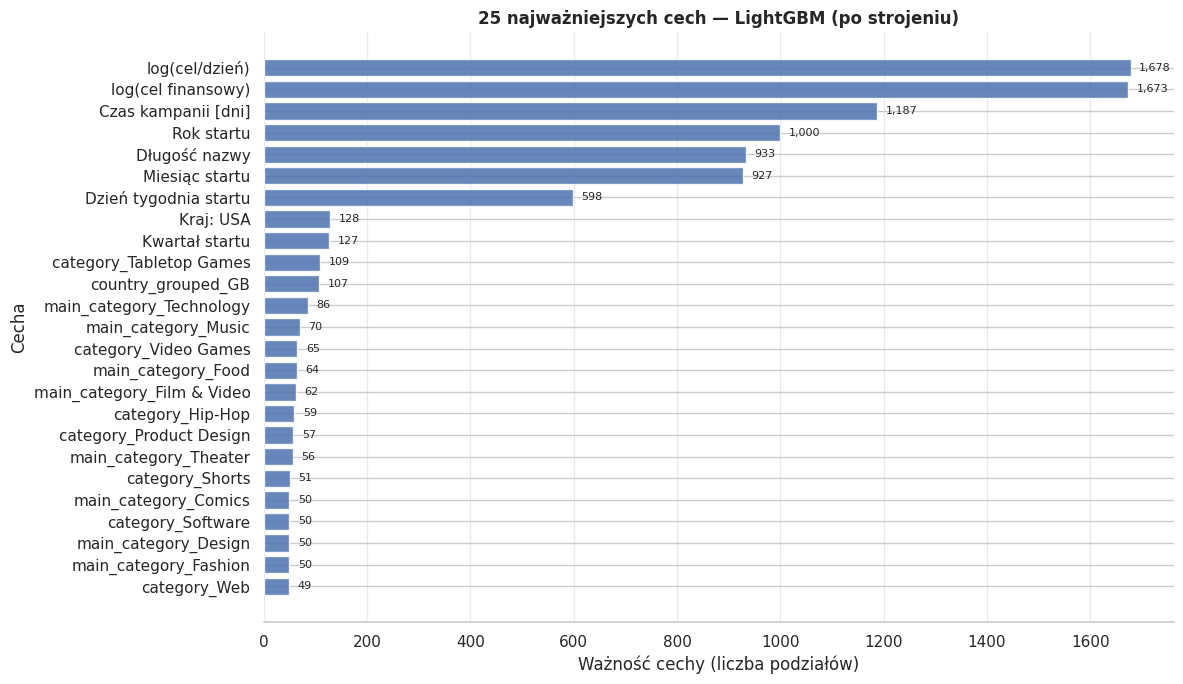

In [26]:
lgbm_clf   = best_model.named_steps['clf']
prep_fit   = best_model.named_steps['prep']
ohe_names  = prep_fit.named_transformers_['cat']['ohe'].get_feature_names_out(CAT_FEATURES).tolist()
feat_names = NUM_FEATURES + ohe_names

# Polskie nazwy cech numerycznych
pl_num_names = {
    'log_goal':          'log(cel finansowy)',
    'log_goal_per_day':  'log(cel/dzień)',
    'campaign_days':     'Czas kampanii [dni]',
    'name_length':       'Długość nazwy',
    'launch_month':      'Miesiąc startu',
    'launch_dayofweek':  'Dzień tygodnia startu',
    'launch_year':       'Rok startu',
    'launch_quarter':    'Kwartał startu',
    'is_usa':            'Kraj: USA',
}
def pl_name(name):
    return pl_num_names.get(name, name)

importance = (
    pd.Series(lgbm_clf.feature_importances_, index=feat_names)
    .sort_values(ascending=False)
    .head(25)
)
importance.index = [pl_name(n) for n in importance.index]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(importance.index[::-1], importance.values[::-1],
               color='#4C72B0', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, importance.values[::-1]):
    ax.text(bar.get_width() + importance.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', fontsize=8)
ax.set_title('25 najważniejszych cech — LightGBM (po strojeniu)', fontweight='bold')
ax.set_xlabel('Ważność cechy (liczba podziałów)')
ax.set_ylabel('Cecha')
sns.despine(ax=ax, left=True)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('phase2/fig2_waznosc_cech.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Finalna ewaluacja na zbiorze testowym

In [23]:
y_test_pred  = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

acc_test = accuracy_score(y_test, y_test_pred)
f1_test  = f1_score(y_test, y_test_pred)
auc_test = roc_auc_score(y_test, y_test_proba)

print('=== Finalna ewaluacja – zbiór testowy ===')
print(f'Accuracy: {acc_test:.4f}')
print(f'F1-Score: {f1_test:.4f}')
print(f'AUC-ROC:  {auc_test:.4f}')
print()
print(classification_report(y_test, y_test_pred, target_names=['Failed', 'Successful']))

=== Finalna ewaluacja – zbiór testowy ===
Accuracy: 0.6859
F1-Score: 0.6490
AUC-ROC:  0.7624

              precision    recall  f1-score   support

      Failed       0.78      0.66      0.72     29657
  Successful       0.59      0.72      0.65     20090

    accuracy                           0.69     49747
   macro avg       0.68      0.69      0.68     49747
weighted avg       0.70      0.69      0.69     49747



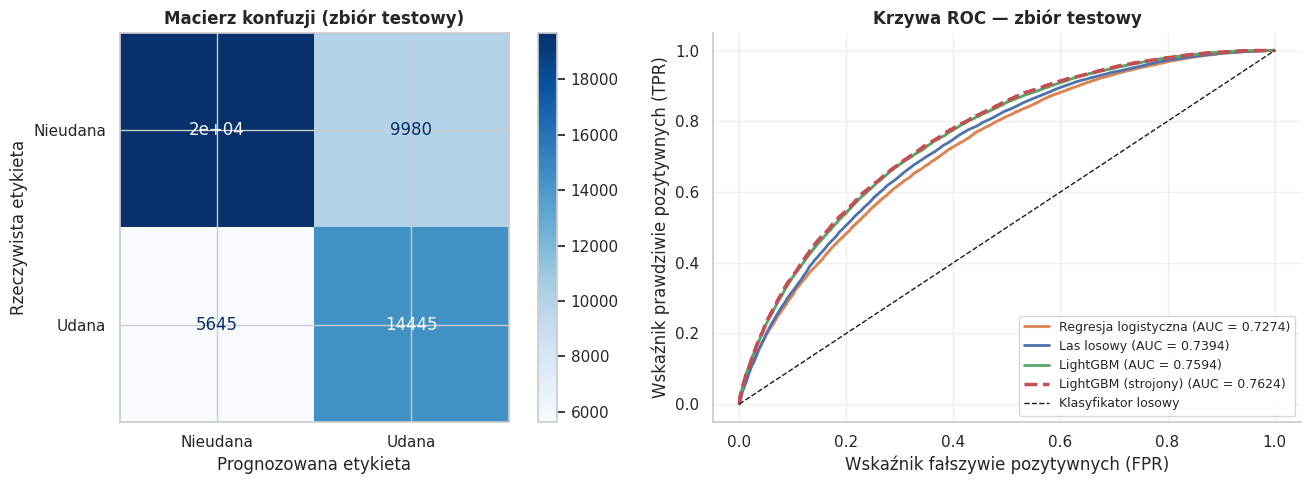

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Macierz konfuzji --
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['Nieudana', 'Udana'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Macierz konfuzji (zbiór testowy)', fontweight='bold')
axes[0].set_xlabel('Prognozowana etykieta')
axes[0].set_ylabel('Rzeczywista etykieta')

# -- Krzywa ROC --
model_colors = {'Logistic Regression': '#DD8452', 'Random Forest': '#4C72B0', 'LightGBM': '#55A868'}
model_pl     = {
    'Logistic Regression': 'Regresja logistyczna',
    'Random Forest':        'Las losowy',
    'LightGBM':             'LightGBM',
}
for mname, mpipe in trained_pipes.items():
    color = model_colors.get(mname, 'gray')
    yp = mpipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yp)
    auc_val = roc_auc_score(y_test, yp)
    axes[1].plot(fpr, tpr, lw=2, color=color,
                 label=f'{model_pl[mname]} (AUC = {auc_val:.4f})')

yp_best = best_model.predict_proba(X_test)[:, 1]
fpr_b, tpr_b, _ = roc_curve(y_test, yp_best)
axes[1].plot(fpr_b, tpr_b, lw=2.5, color='#C44E52', linestyle='--',
             label=f'LightGBM (strojony) (AUC = {auc_test:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Klasyfikator losowy')
axes[1].set_xlabel('Wskaźnik fałszywie pozytywnych (FPR)')
axes[1].set_ylabel('Wskaźnik prawdziwie pozytywnych (TPR)')
axes[1].set_title('Krzywa ROC — zbiór testowy', fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
sns.despine(ax=axes[1])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase2/fig3_macierz_roc.png', dpi=150, bbox_inches='tight')
plt.show()
